# 📘 Домашнє завдання №20. Курсовий проєкт

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW20_Course_Project

Dataset: https://www.kaggle.com/datasets/rohitudageri/credit-card-details  
Тип задачі: Binary Classification  
Мета: побудувати повний ML pipeline від raw data до explainable model

---

# Бізнес-контекст

Вам потрібно побудувати модель, яка передбачає:
чи буде заявка на кредитну картку схвалена або відхилена

Це класична задача credit scoring, де важливі:
- ризик дефолту
- стабільність доходів
- кредитна історія
- демографічні фактори

---

# Етап 1 — Data Understanding & EDA

Що потрібно зробити:
- перевірити розподіл таргету (imbalance)
- описати кожну змінну
- знайти категоріальні/числові фічі
- перевірити пропуски та аномалії

Підказки:
- income може бути skewed (log-transform корисний)
- age можуть бути outliers
- credit history length може містити нулі або пропуски
- категоріальні змінні можуть включати education, marital status, occupation
- можливий сильний imbalance target

Обов’язково зробити:
- histograms для числових фіч
- bar plots для категоріальних фіч
- correlation heatmap
- target distribution plot

---

# Етап 2 — Data Cleaning

Що потрібно:
- обробити missing values
- привести типи змінних
- обробити duplicates
- перевірити inconsistent categories

Підказки:
- missing income краще заповнювати median або grouped imputation
- категорії можуть містити unknown, other, ?
- перевірити аномалії:
  - negative income
  - age < 18

---

# Етап 3 — Feature Engineering

Що потрібно створити:

Risk-based features:
- income per age
- credit history ratio
- debt-to-income proxy (якщо є борги)

Binning features:
- age groups (18–25, 25–40, 40–60, 60+)
- income quartiles

Interaction features:
- income × employment status
- credit history × age

Binary flags:
- high income flag
- young applicant flag
- no credit history flag

Порада:
не створювати надто багато фіч, краще менше, але якісних

---

# Етап 4 — Feature Selection

Використати мінімум 2 методи:
- correlation analysis
- mutual information
- tree-based importance (Random Forest або XGBoost)
- permutation importance

Мета:
- прибрати шумові фічі
- залишити стабільні предиктори
- пояснити вибір фіч

---

# Етап 5 — Model Selection (Cross-Validation)

Порівняти 3 моделі (наприклад):
- Logistic Regression
- Random Forest
- XGBoost

Вимоги:
- StratifiedKFold (5 folds)
- ROC-AUC як основна метрика
- порівняти mean і std

Порада:
- перевірити imbalance
- оцінити стабільність Logistic Regression
- перевірити реальний gain від XGBoost

---

# Етап 6 — Hyperparameter Tuning

Обов’язково:
- XGBoost tuning (Optuna або GridSearch)
- або Logistic Regression GridSearch

Параметри XGBoost:
- max_depth
- learning_rate
- n_estimators
- subsample
- colsample_bytree
- reg_lambda
- reg_alpha

Порада:
не тюнити всі параметри одночасно, робити поетапно

---

# Етап 7 — Evaluation

Обов’язкові метрики:
- ROC-AUC
- Precision
- Recall
- F1-score
- Confusion Matrix

Важливо:
- не використовувати лише accuracy
- аналізувати recall для позитивного класу

---

# Етап 8 — Explainability

Використати мінімум 2 методи:
- Logistic Regression coefficients
- Feature Importance
- RuleFit
- SHAP для XGBoost

Пояснити:
- які фактори впливають на approval
- як змінюється ризик
- локальні пояснення для окремих прикладів

---

# Етап 9 — Error Analysis

Проаналізувати:
- false positives
- false negatives

Перевірити:
- чи є закономірності в помилках
- чи пов’язані вони з income, age, credit history

---

# Очікуваний результат

Ви повинні отримати:
- чистий датасет
- engineered features
- порівняння моделей через CV
- tuned фінальну модель
- explainability аналіз
- бізнес-інсайти

---

# Критерії оцінювання

EDA + cleaning 20%
Feature engineering 20%
Model comparison 20%
Tuning 15%
Explainability 15%
Insights + conclusions 10%

---

# Фінальний меседж

Мета роботи — не побудувати найкращу модель, а навчитися пояснювати, чому модель приймає рішення.

In [1]:
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
#     "pandas",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# # Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "kagglehub[pandas-datasets]",
#     "numpy",
#     "matplotlib",
#     "scipy",
#     "statsmodels",
#     "joblib",
#     "seaborn",
#     "sklearn",
#     "skrub",
#     "mpl_toolkits",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# # Synchronization with remote source
#
# import shutil
# from pathlib import Path
#
# # Input data
hm_version = 20
#
# # Solution
# git_project_url = f"https://github.com/BogdanPinchuk/DataScience-PBY_HW{hm_version}_Course_Project.git"
# main_file_name = f"Bohdan_Pinchuk_DS_HW{hm_version}.ipynb"
#
# # upload all files
# current_path = !pwd
# current_path = current_path[0]
# parent_path = !dirname "$current_path"
# parent_path = parent_path[0]
# temp_path = f"{parent_path}/temp"
#
# # Clone data
# !rm -rf "$temp_path"
# !git clone "$git_project_url" "$temp_path"
#
# source = Path(temp_path)
# destination = Path(current_path)
# exclude = {main_file_name, ".git", ".idea"}
#
# for item in source.iterdir():
#     if item.name in exclude:
#         continue
#
#     target = destination / item.name
#     if item.is_dir():
#         shutil.copytree(item, target, dirs_exist_ok=True)
#     else:
#         shutil.copy2(item, target)
#
# # Clean temp folder
# !rm -rf "$temp_path"

# ✳️ Підготовка датасетів

In [3]:
# Downloading data

import gc
import pandas as pd
import apps.main as mn
from IPython.display import display
from IPython.core.display import Markdown

# Input data
target_value = "label"
cat_values_1 = ["Mobile_phone", "Work_Phone", "Phone", "EMAIL_ID"]
cat_values_2 = ["Car_Owner", "Propert_Owner"]
update_db = False
db_file_name = f"resources/store_hw{hm_version}.db"

# Solution
pd.options.display.float_format = "{:g}".format
credit_card_details_dataset = mn.download_and_extract_from_kagglehub("rohitudageri/credit-card-details",
                                                                     "Credit_card.csv",
                                                                     db_file_name,
                                                                     update_db=update_db)

credit_card_labels_dataset = mn.download_and_extract_from_kagglehub("rohitudageri/credit-card-details",
                                                                    "Credit_card_label.csv",
                                                                    db_file_name,
                                                                    ds_name="credit_card_labels",
                                                                    update_db=update_db)

# робимо заміну для кращого сприйняття:
# 0 - true, а 1 - false по схваленні заявки
credit_card_labels_dataset[target_value] = credit_card_labels_dataset[target_value].map({0: True, 1: False})
# робимо заміну для кращого сприйняття:
# деякі значення кодовані як числові, але для попереднього аналізу перетворимо їх у категоріальний тип
# 0 - false, 1 - true по наявності можливості зв'язатись із клієнтом
for col_name in cat_values_1:
    credit_card_details_dataset[col_name] = credit_card_details_dataset[col_name].map({0: False, 1: True})
# деякі значення кодовані як символ, але для попереднього аналізу перетворимо їх сприйнятливий формат
# N - false, Y - true по наявності якоїсь власності
for col_name in cat_values_2:
    credit_card_details_dataset[col_name] = credit_card_details_dataset[col_name].map({"N": False, "Y": True})

# Merge
credit_card_dataset = (
    pd.merge(credit_card_details_dataset, credit_card_labels_dataset, on="Ind_ID", how="outer"))  # type: ignore

del credit_card_details_dataset, credit_card_labels_dataset

# Print result
# display(credit_card_dataset)

# Clean
_ = gc.collect()

# ✅ Рішення: Етап 1 — Data Understanding & EDA

Що потрібно зробити:
- перевірити розподіл таргету (imbalance)
- описати кожну змінну
- знайти категоріальні/числові фічі
- перевірити пропуски та аномалії

Підказки:
- income може бути skewed (log-transform корисний)
- age можуть бути outliers
- credit history length може містити нулі або пропуски
- категоріальні змінні можуть включати education, marital status, occupation
- можливий сильний imbalance target

Обов’язково зробити:
- histograms для числових фіч
- bar plots для категоріальних фіч
- correlation heatmap
- target distribution plot

In [4]:
# Data description

import numpy as np
import pandas as pd
import apps.reporter as rpt
from IPython.display import display
from IPython.core.display import Markdown

# Input data
n_first_rows = 5
balans_level = 0.1
ds_name = "Credit card Details"

# Solution
data_set = credit_card_dataset

n_columns = data_set.columns.size
n_rows = data_set.index.size

# для правильного відображення в таблиці змінимо формат
data_set["Ind_ID"] = data_set["Ind_ID"].astype('category')

col_num_type = data_set.select_dtypes(include=np.number)
col_cat_type = data_set.select_dtypes(exclude=np.number)

for col_name in col_cat_type:
    data_set[col_name] = data_set[col_name].astype('category')

types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

empty_val_by_col = data_set.isna().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.columns.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.columns.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

sorted_target_values_count = data_set[target_value].value_counts().tolist()
max_contrast = mn.contrast(min(sorted_target_values_count), max(sorted_target_values_count))  # type: ignore

rp1 = rpt.Reporter()
rp1.add_item("Рівень датасету,\nпри якому він буде вважатися збалансованим", f"{balans_level:.2%}")
rp1.add_item("Датасет збалансований", 'так' if max_contrast <= balans_level else 'ні')
rp1.add_item("Максимальна відмінність між класами", f"{max_contrast:.2%}")

# Print results
display(Markdown(f"### Аналіз даних"))
display(data_set.head(n_first_rows).style.
        format("{:g}", subset=col_num_type.columns).
        set_caption(f"Перші {n_first_rows} рядків датасету"))

rp.print_pd_report("Параметри таблиці")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))
display(types_df.style.set_caption("Типи даних"))

display(col_num_type.describe().T.style.format("{:g}").set_caption("Статистика числових змінних"))

display(col_cat_type.drop("Ind_ID", axis=1).describe().T.style.set_caption("Статистика для категоріальних змінних"))

for col_name in col_cat_type.drop("Ind_ID", axis=1):
    display(pd.concat([
        col_cat_type[col_name].value_counts(),
        col_cat_type[col_name].value_counts(normalize=True)
    ], axis=1).style.set_caption(f"Категорія: \"{col_name}\""))

display(pd.concat([
    data_set[target_value].value_counts(),
    data_set[target_value].value_counts(normalize=True),
], axis=1).style.set_caption("Цільова змінна"))

rp1.print_pd_report("Збалансованість датасету за цільовою змінною")

### Аналіз даних

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,True,True,0,180000,Pensioner,Higher education,Married,House / apartment,-18772,365243,True,False,False,False,nan,2,False
1,5008865,F,True,True,2,135000,Working,Secondary / secondary special,Married,House / apartment,-15761,-3173,True,False,False,False,Laborers,4,True
2,5008889,F,False,True,0,247500,Commercial associate,Higher education,Separated,Rented apartment,-17016,-1347,True,False,False,False,Core staff,1,True
3,5009000,M,True,True,0,157500,Working,Secondary / secondary special,Married,House / apartment,-9927,-828,True,False,False,False,Drivers,2,True
4,5009023,F,False,True,2,216000,State servant,Higher education,Married,House / apartment,-15444,-3112,True,False,False,True,nan,4,True


Attribute,Result
Кількість рядків,1548
Кількість стовпців,19
Кількість числових ознак,5
Кількість категоріальних ознак,14
Пропущені значення,є


,count
Ind_ID,0
GENDER,7
Car_Owner,0
Propert_Owner,0
CHILDREN,0
Annual_income,23
Type_Income,0
EDUCATION,0
Marital_status,0
Housing_type,0


,Types
Ind_ID,category
GENDER,category
Car_Owner,category
Propert_Owner,category
CHILDREN,int64
Annual_income,float64
Type_Income,category
EDUCATION,category
Marital_status,category
Housing_type,category


...

,count,proportion
EMAIL_ID,,
False,1405,0.907623
True,143,0.092377


,count,proportion
Type_Occupation,,
Laborers,268,0.252830
Core staff,174,0.164151
Managers,136,0.128302
Sales staff,122,0.115094
Drivers,86,0.081132
High skill tech staff,65,0.061321
Medicine staff,50,0.047170
Accountants,44,0.041509
Security staff,25,0.023585


,count,proportion
label,,
True,1373,0.886951
False,175,0.113049


,count,proportion
label,,
True,1373,0.886951
False,175,0.113049


Attribute,Result
"Рівень датасету, при якому він буде вважатися збалансованим",10.00%
Датасет збалансований,ні
Максимальна відмінність між класами,77.39%


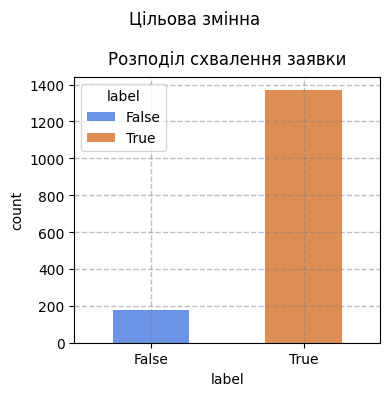

In [5]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data
data_set = credit_card_dataset

# Solution
_, ax = plt.subplots(figsize=(4, 4))

sns.countplot(data=data_set, ax=ax, x=target_value, hue=target_value, width=0.5, dodge=False)

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Розподіл схвалення заявки", pad=10, loc='center', color='black')

plt.suptitle("Цільова змінна")

plt.tight_layout()
plt.show()

Опис змінних:
- **Ind_ID** — ідентифікатор клієнта (змінна необхідна лише для поєднання 2-х таблиць);
- **GENDER** — стать:
    - "F" — жіноча;
    - "M" — чоловіча;
- **Car_Owner** — чи є власником авто;
- **Propert_Owner** — чи є власником нерухомості;
- **CHILDREN** — скільки має дітей;
- **Annual_income** — річний дохід;
- **Type_Income** — джерело доходу:
    - "Working" — найманий працівник;
    - "Commercial associate" — комерційний партнер / підприємець;
    - "Pensioner" — пенсіонер;
    - "State servant" — державний службовець / бюджетник;
- **EDUCATION** — освіта (чіткі рівні/ранги):
    1) "Lower secondary" — базова загальна середня освіта;
    2) "Secondary / secondary special" — повна середня або середня спеціальна освіта;
    3) "Incomplete higher" — незакінчена вища освіта;
    4) "Higher education" — вища освіта;
    5) "Academic degree" — науковий ступінь;
- **Marital_status** — сімейний стан:
    - "Married" — перебуває у шлюбі (одружений / заміжня);
    - "Single / not married" — неодружений / незаміжня;
    - "Civil marriage" — цивільний шлюб (спільне проживання без офіційної реєстрації);
    - "Separated" — проживає окремо / розлучений(а) (офіційно у шлюбі, але разом не живуть, або в процесі розлучення);
    - "Widow" - вдівець / вдова;
- **Housing_type** — тип житла:
    - "House / apartment" — власний будинок / квартира;
    - "With parents" — проживає з батьками;
    - "Municipal apartment" — комунальна / державна квартира;
    - "Rented apartment" — орендоване житло;
    - "Office apartment" — службове житло;
    - "Co-op apartment" — кооперативна квартира;
- **Birthday_count** — вік клієнта у днях, але мінус значення відраховується у зворотному напрямку, починаючи від сьогоднішнього дня (-1 — учора);
- **Employed_days** — трудовий стаж у днях, де мінус че кількість днів від прийняття на роботу (значення відраховуються у зворотному напрямку), а додатні значення — це кількість днів безробіття;
- **Mobile_phone** — наявність мобільного телефону;
- **Work_Phone** — наявність робочого телефону;
- **Phone** — наявність домашнього телефону;
- **EMAIL_ID** — наявність e-mail;
- **Type_Occupation** — конкретна сфера/тип професії;
    - "Laborers" — кваліфіковані робітники / чорноробочі (загальний виробничий чи будівельний персонал);
    - "Core staff" — основний персонал / ключові співробітники (штатні фахівці, офісні працівники середньої ланки);
    - "Managers" — менеджери / керівники (управлінський персонал);
    - "Sales staff" — персонал з продажів (продавці, торгові представники, консультанти);
    - "Drivers" — водії (логістика, транспорт);
    - "High skill tech staff" — висококваліфікований технічний персонал (інженери, технологи, майстри);
    - "Medicine staff" — медичний персонал (лікарі, медсестри, фармацевти);
    - "Accountants" — бухгалтери / фінансисти;
    - "Security staff" — персонал служби безпеки / охоронці;
    - "Cleaning staff" — персонал з прибирання / клінінг;
    - "Cooking staff" — кухарі / персонал кухні;
    - "Private service staff" — персонал приватних послуг (домогосподарки, няні, особисті помічники);
    - "Low-skill Laborers" — некваліфіковані робітники (різно-робочі, вантажники, підсобні працівники);
    - "Secretaries" — секретарі / офіс-менеджери;
    - "Waiters/barmen staff" — офіціанти / бармени (сфера обслуговування);
    - "HR staff" — спеціалісти з кадрів / HR-менеджери;
    - "IT staff" — ІТ-спеціалісти (розробники, сисадміни, аналітики);
    - "Realty agents" — агенти з нерухомості / ріелтори;
- **Family_Members** — кількість членів родини (розмір сімʼї);
- **label** — статус заявки/кредиту: схвалено або відхилено (цільова змінна);

In [6]:
# Outliers and Anomalies

import numpy as np
import apps.main as mn
import apps.reporter as rpt
from joblib import Parallel, delayed

# Input data
convert_col = ["Birthday_count", "Employed_days"]
converted_col_name = ["Birthday_years", "Employed_years"]
log_transform_col_orig = "Annual_income"
log_transform_col_new = "Annual_income_log"
data_set = credit_card_dataset.copy()

# Solution
# конвертуємо для кращого сприйняття викидів і їх аналізу
for idx, col_name in enumerate(convert_col):
    data_set[converted_col_name[idx]] = (data_set[col_name].values / 365.25).round(2).astype(float)

data_set[log_transform_col_orig] = data_set[log_transform_col_orig].abs()
data_set[log_transform_col_new] = np.log1p(data_set[log_transform_col_orig])
# поміняємо місцями назви колонок для аналізу
data_set = data_set.rename(columns={
    log_transform_col_orig: log_transform_col_new,
    log_transform_col_new: log_transform_col_orig
})

outliers_analysis = Parallel(n_jobs=-1)(
    delayed(mn.calc_outliers)(col_cat_type["Ind_ID"], column_series)
    for column_series in [col_num_type[col_name] for col_name in col_num_type]
)

# повернемо оригінальні назви колонок
data_set = data_set.rename(columns={
    log_transform_col_orig: log_transform_col_new,
    log_transform_col_new: log_transform_col_orig
})
data_set.drop(log_transform_col_new, axis=1, inplace=True)

rp = rpt.Reporter()
for col_name, n_outliers, _ in outliers_analysis:
    if n_outliers > 0:
        rp.add_item(f"{col_name}", str(n_outliers))

df_outliers = []
df_anomalies = []
for col_name, n_outliers, outliers in outliers_analysis:
    if n_outliers > 0:
        temp_ds = data_set[data_set["Ind_ID"].isin(outliers)]
        if col_name in convert_col:
            idx_col = convert_col.index(col_name)
            temp_ds = temp_ds[converted_col_name[idx_col]].value_counts().to_frame()
        else:
            temp_ds = temp_ds[col_name].value_counts().to_frame()

        max_value = temp_ds.index.max()
        df_anomalies.append((col_name, max_value))

        df_outliers.append(temp_ds)
        # df_outliers.append(temp_ds.style.format_index("{:g}").set_caption(f"Outliers for feature: {col_name}"))

rp1 = rpt.Reporter()
for col_name, anomalous_value in df_anomalies:
    rp1.add_item(f"{col_name}", str(anomalous_value))

# чистимо аномалії
for col_name, anomalous_value in df_anomalies:
    col_name2 = col_name
    if col_name in convert_col:
        idx_col = convert_col.index(col_name)
        col_name2 = converted_col_name[idx_col]

    anomalous_indexes = data_set[data_set[col_name2] == anomalous_value].index.tolist()

    for anomalous_index in anomalous_indexes:
        if col_name2 == "Employed_years":
            credit_card_dataset.at[anomalous_index, col_name] = 0
        else:
            credit_card_dataset.at[anomalous_index, col_name] = np.nan

# Print results
# перевірка віку
temp_df = data_set[data_set["Birthday_years"] > -18]
if len(temp_df) > 0:
    display(temp_df.style.format("{:g}", subset=col_num_type.columns).
            set_caption("Аномалія: вік клієнта менше ніж 18 років"))

# перевірка трудового стажу
temp_df = data_set[(data_set["Employed_years"] < 0) & (data_set["Birthday_years"] + 18 > data_set["Employed_years"])]
if len(temp_df) > 0:
    display(temp_df.style.format("{:g}", subset=col_num_type.columns).
            set_caption("Аномалія: людина почала працювати раніше, ніж їй виповнилося 18 років"))

# перевірка відʼємного доходу
temp_df = data_set[data_set["Annual_income"] < 0]
if len(temp_df) > 0:
    display(temp_df.style.format("{:g}", subset=col_num_type.columns).
            set_caption("Аномалія: дохід клієнта менше ніж 0"))

rp.print_pd_report("Кількість викидів/outliers")

for df_outlier in df_outliers:
    display(df_outlier)

rp1.print_pd_report("Аномальні значення")

# виводимо та чистимо аномалії
for col_name, anomalous_value in df_anomalies:
    if col_name in convert_col:
        idx_col = convert_col.index(col_name)
        col_name = converted_col_name[idx_col]
    temp_ds = data_set[data_set[col_name] == anomalous_value]

    if len(temp_ds) > 10:
        temp_ds = (temp_ds.groupby(["Type_Income", col_name]).
                   size().to_frame(name="count").
                   style.set_caption(f"Anomalies for feature: {col_name}"))
        display(temp_ds)
    else:
        display(temp_ds.style.format("{:g}", subset=col_num_type.columns).
                set_caption(f"Anomalies for feature: {col_name}"))

# display(data_set)

Attribute,Result
CHILDREN,18
Annual_income,73
Employed_days,339
Family_Members,17


,count
CHILDREN,
3,16
14,1
4,1


,count
Annual_income,
450000,29
405000,9
391500,4
900000,4
495000,3
540000,3
585000,3
445500,2
612000,2


,count
Employed_years,
999.98,261
-22.02,3
-22.93,3
-23.78,2
-21.99,2
...,...
-23.21,1
-20.1,1
-22.53,1


,count
Family_Members,
5,15
15,1
6,1


Attribute,Result
CHILDREN,14
Annual_income,1575000.0
Employed_days,999.98
Family_Members,15


,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label,Birthday_years,Employed_years
595,5061207,M,True,True,14,225000,Working,Secondary / secondary special,Separated,House / apartment,-17754,-1689,True,False,False,False,Drivers,15,True,-48.610000,-4.620000


,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label,Birthday_years,Employed_years
1444,5143231,F,True,True,1,1.575e+06,Commercial associate,Higher education,Single / not married,House / apartment,-10142,-2479,True,False,False,False,Managers,2,True,-27.770000,-6.790000
1445,5143235,F,True,True,1,1.575e+06,Commercial associate,Higher education,Single / not married,House / apartment,-10142,-2479,True,False,False,False,Managers,2,True,-27.770000,-6.790000


,,count
Type_Income,Employed_years,
Pensioner,999.980000,261


,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label,Birthday_years,Employed_years
595,5061207,M,True,True,14,225000,Working,Secondary / secondary special,Separated,House / apartment,-17754,-1689,True,False,False,False,Drivers,15,True,-48.610000,-4.620000


Висновок. Датасет показує сильний дисбаланс. У датасеті наявні пропуски та незвичні аномалії, які вимагають перевірки. Також під час аналізу аномалій були виявлені дублікати. Аналіз клієнта з аномалією в 14 дітей і загалом 15 членів у сімʼї, виглядає як помилка заповнення даних, звичайно можна взяти дітей із притулку, але вказаний дохід не є реальним, щоб забезпечити таку велику сімʼю, враховуючи, що клієнт неодружений, припускаючи, що випадково була введена цифра "1" на початку, навіть наявність 4 дітей має сумнівний вигляд. Що до багатія, то все залежить від того, як рахується стаж роботи, але в цьому випадку, маючи вік 28 років і досвіду всього 7 років, виглядає неправдоподібно, хоч це керівна посада та вона є підприємцем. В реальності такий дохід можливий, але на рівні C-level, коли дана особа має опціони чи акції компанії, і дана особа має понад 20 років досвіду та працювала в різних компаніях. Або, можливо, це дочка/дружина власника компанії та має свою частку. Аномалії, що до трудового стажу помітні лише для пенсіонерів, імовірніше за все це якась програмна константа для фільтрації даних, оскільки тисяча років трудового досвіду при максимальному вікові, який є в таблиці та рівний майже 69 років, має помилковий вигляд.

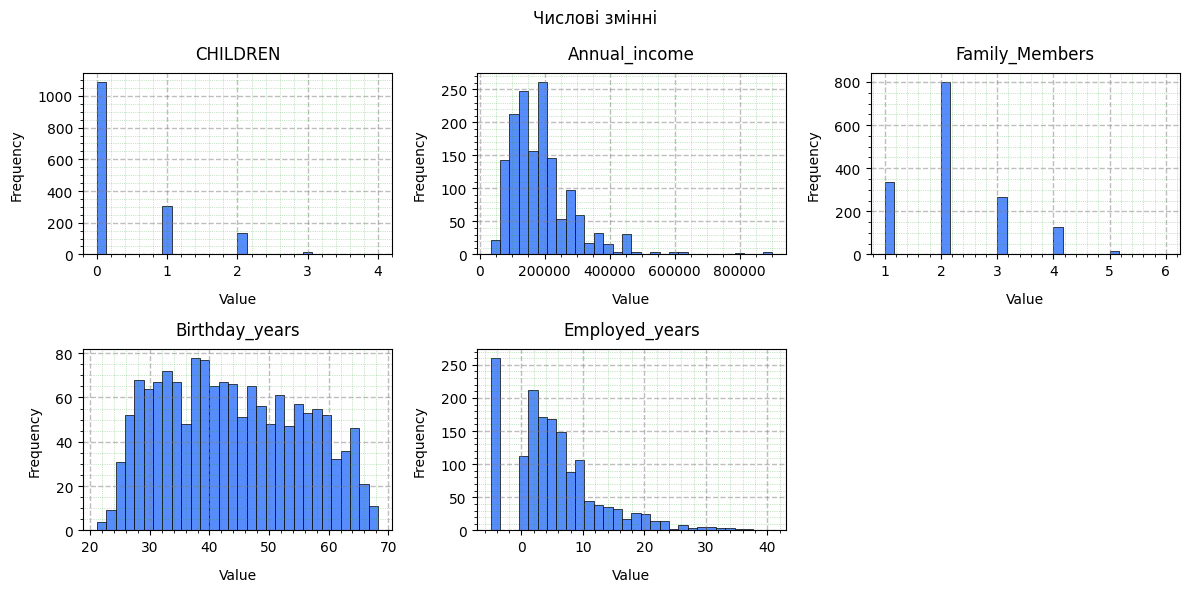

In [7]:
# Graphic results

import numpy as np
import matplotlib.pyplot as plt

# Input data
n_bins = 30
n_columns = 3
data_set = credit_card_dataset.copy()

# Solution
# конвертуємо для кращого сприйняття
data_set["Employed_days"] = [value if value < 0 else 0 for value in data_set["Employed_days"]]
for idx, col_name in enumerate(convert_col):
    data_set[converted_col_name[idx]] = np.abs(data_set[col_name].values / 365.25).round(2).astype(float)
    data_set.drop(col_name, axis=1, inplace=True)
data_set["Employed_years"] = [value if value != 0 else -5 for value in data_set["Employed_years"]]

col_num_type = data_set.select_dtypes(include=np.number)

axes = col_num_type.hist(layout=(-1, n_columns), figsize=(12, 6),
                         bins=n_bins, edgecolor="black", linewidth=0.5, sharex=False, sharey=False)

for i, ax in enumerate(axes.flatten()):
    ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
    ax.minorticks_on()
    ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
    ax.set_title(ax.get_title(), pad=10, loc='center', color='black')
    ax.set_xlabel("Value", labelpad=10, loc='center', color='black')
    ax.set_ylabel("Frequency", labelpad=10, loc='center', color='black')

plt.suptitle("Числові змінні")

plt.tight_layout()
plt.show()


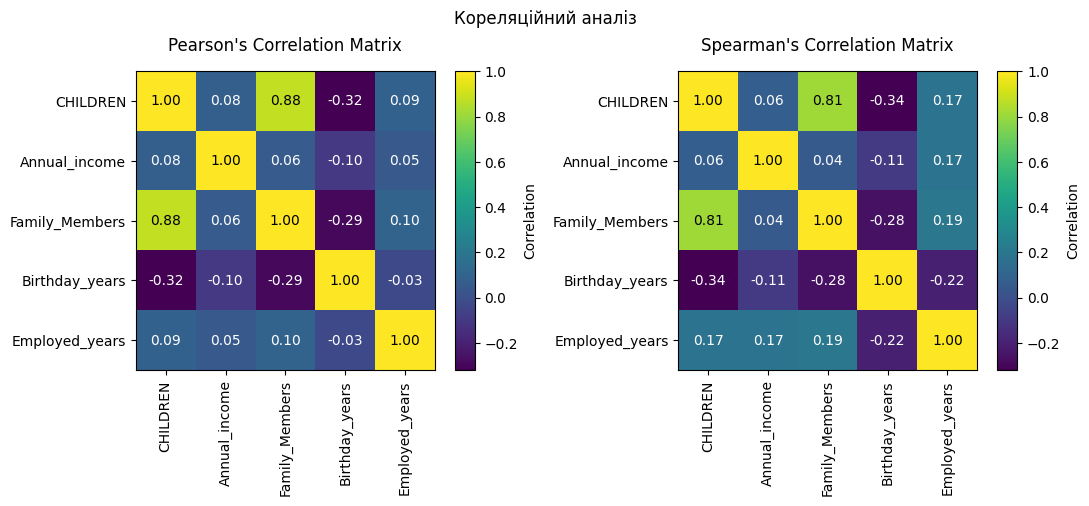

In [8]:
# Graphic results

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Input data
tolerance = 2
color_spliter = 0.5
data_set = col_num_type.copy()

# Solution
data_set["Employed_years"] = [value if value > 0 else 0 for value in data_set["Employed_years"]]

# Pearson
pearson_matrix = data_set.corr(method='pearson').round(tolerance)
# Spearman
spearman_matrix = data_set.corr(method='spearman').round(tolerance)

_, axes = plt.subplots(1, 2, figsize=(11, 5))

ax = axes[0]
data_matrix = pearson_matrix
ax.imshow(data_matrix)
ax.set_yticks(range(len(data_matrix)), labels=data_matrix.index)
ax.set_xticks(range(len(data_matrix)), labels=data_matrix.columns)
plt.setp(ax.get_xticklabels(), rotation=90)

for i in range(len(data_matrix.index)):
    for j in range(len(data_matrix.columns)):
        corr_val = data_matrix.iloc[i, j]
        ax.text(j, i, f"{corr_val:.{tolerance}f}",
                ha="center", va="center",
                color="white" if corr_val <= color_spliter else "black")

divider = make_axes_locatable(ax)
cb_ax = divider.append_axes("right", size=0.2, pad=0.2)

norm = plt.Normalize(pearson_matrix.min().min(), pearson_matrix.max().max())
sm = plt.cm.ScalarMappable(norm=norm)
sm.set_array([])
ax.figure.colorbar(sm, cax=cb_ax, label='Correlation')

ax.set_title("Pearson's Correlation Matrix", pad=15, loc='center', color='black')

ax = axes[1]
data_matrix = spearman_matrix
ax.imshow(data_matrix)
ax.set_yticks(range(len(data_matrix)), labels=data_matrix.index)
ax.set_xticks(range(len(data_matrix)), labels=data_matrix.columns)
plt.setp(ax.get_xticklabels(), rotation=90)

for i in range(len(data_matrix.index)):
    for j in range(len(data_matrix.columns)):
        corr_val = data_matrix.iloc[i, j]
        ax.text(j, i, f"{corr_val:.{tolerance}f}",
                ha="center", va="center",
                color="white" if corr_val <= color_spliter else "black")

divider = make_axes_locatable(ax)
cb_ax = divider.append_axes("right", size=0.2, pad=0.2)

norm = plt.Normalize(pearson_matrix.min().min(), pearson_matrix.max().max())
sm = plt.cm.ScalarMappable(norm=norm)
sm.set_array([])
ax.figure.colorbar(sm, cax=cb_ax, label='Correlation')

ax.set_title("Spearman's Correlation Matrix", pad=15, loc='center', color='black')

plt.suptitle(f"Кореляційний аналіз")

plt.tight_layout()
plt.show()

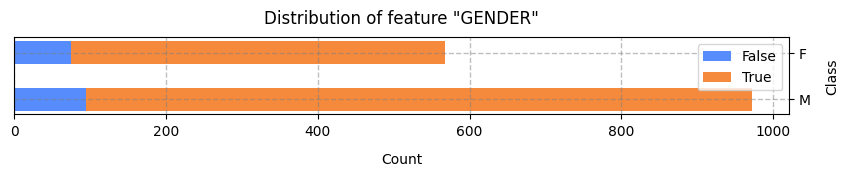

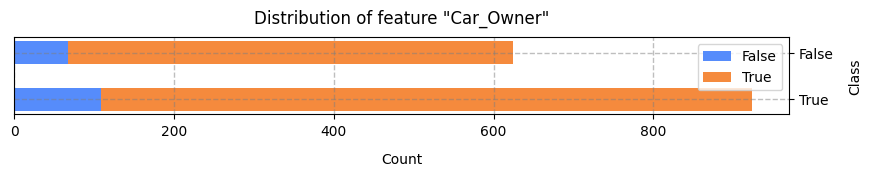

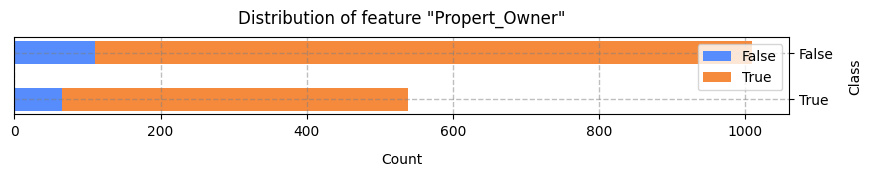

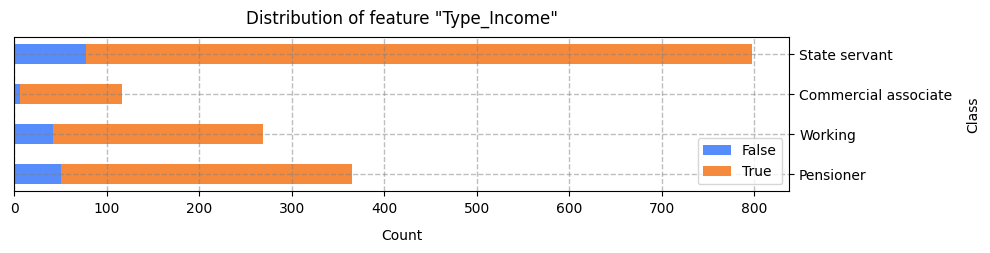

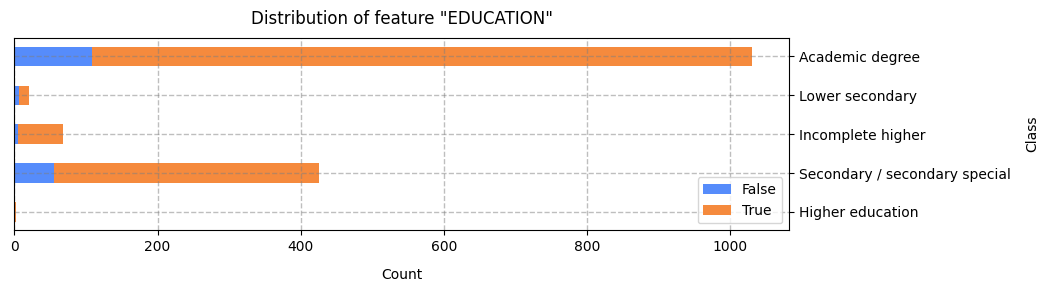

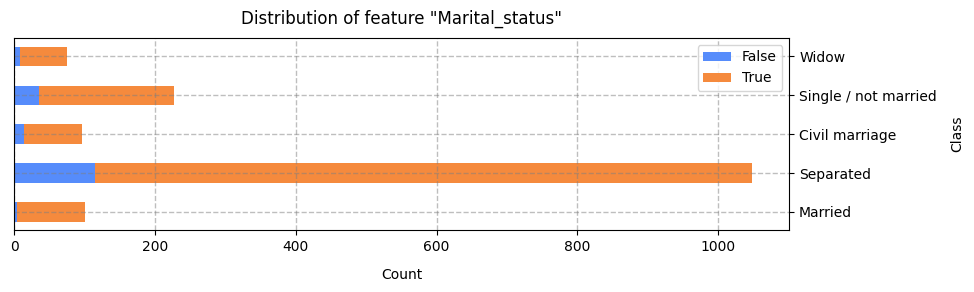

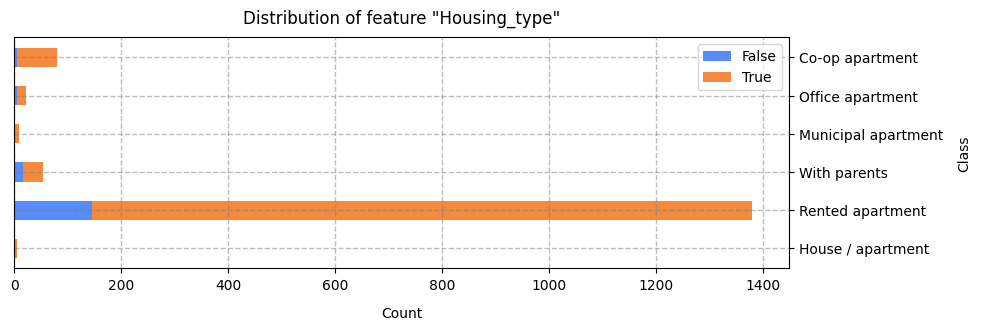

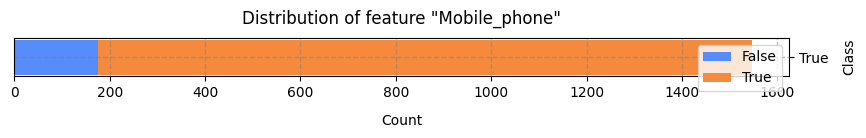

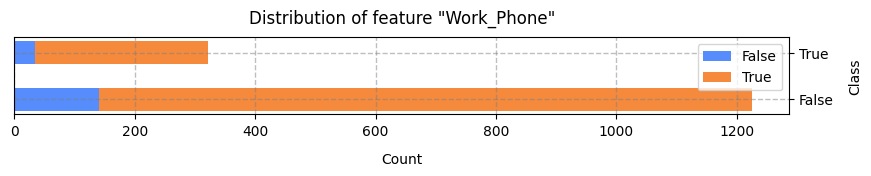

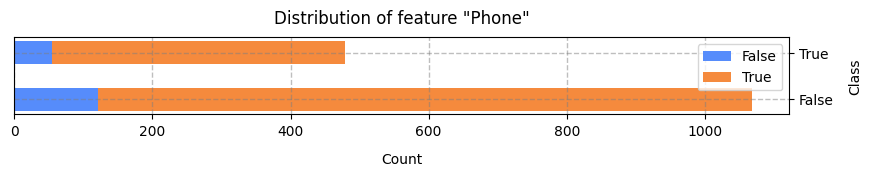

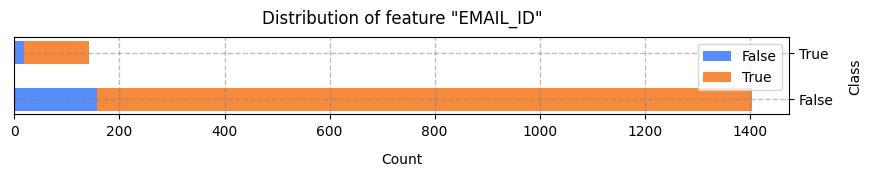

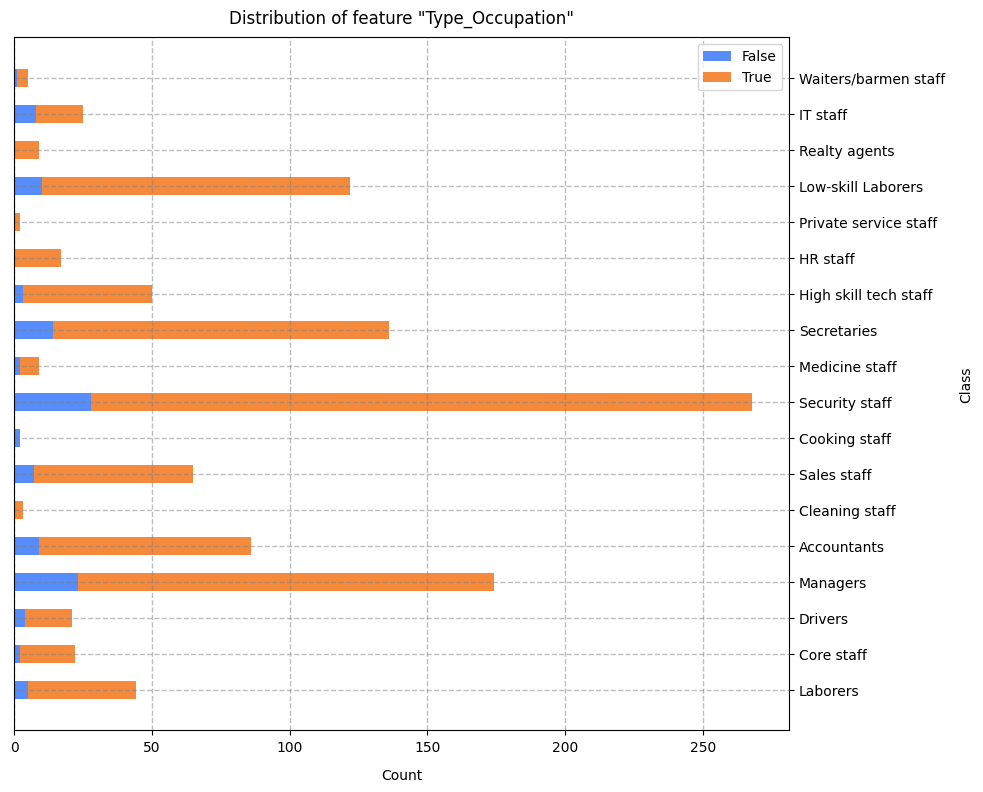

In [9]:
# Graphic results

import numpy as np
import matplotlib.pyplot as plt

# Input data
height = 0.5
data_set = credit_card_dataset.copy()

# Solution
col_cat_type = data_set.select_dtypes(exclude=np.number)

col_target_type = col_cat_type[target_value]
label_types = col_target_type.unique().tolist()

col_cat_type.drop(["Ind_ID"], axis=1, inplace=True)

for column_series in [col_cat_type[col_name] for col_name in col_cat_type.drop(target_value, axis=1).columns]:
    temp_df = col_cat_type.groupby([target_value, column_series.name], observed=False).size().to_frame(name="count")

    label_type_counts = {}
    for label_type in label_types:
        label_type_counts[label_type] = temp_df.loc[label_type]["count"].values

    classes = column_series.dropna().unique().astype(str).tolist()

    left = np.zeros(len(classes))

    height_chart = 0.5 * len(classes)
    _, ax = plt.subplots(figsize=(10, height_chart))
    for label_type, label_counts in label_type_counts.items():
        p = ax.barh(classes, label_counts, height=height, label=label_type, left=left)
        left += label_counts
        # ax.bar_label(p, label_type='center')
    ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')

    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")

    ax.set_title(f"Distribution of feature \"{column_series.name}\"", pad=10, loc='center', color='black')
    ax.set_xlabel("Count", labelpad=10, loc='center', color='black')
    ax.set_ylabel("Class", labelpad=10, loc='center', color='black')

    ax.legend()
    plt.show()


# ✅ Рішення: Етап 2 — Data Cleaning

Що потрібно:
- обробити missing values
- привести типи змінних
- обробити duplicates
- перевірити inconsistent categories

Підказки:
- missing income краще заповнювати median або grouped imputation
- категорії можуть містити unknown, other, ?
- перевірити аномалії:
  - negative income
  - age < 18

In [10]:
# Processing inconsistent categories

from skrub import Cleaner

# Input data

# Solution
cleaner = Cleaner()
credit_card_dataset = cleaner.fit_transform(credit_card_dataset)

# Print results
# display(credit_card_dataset)

In [11]:
# Analysis of the missing

# Input data
nan_con_name = "NaN_count"
data_set = credit_card_dataset.copy()

# Solution
# розраховуємо кількість пропусків у кожному рядку
data_set[nan_con_name] = data_set.isna().sum(axis=1)
# визначаємо, які колонки мають пропуски
cols_with_nan = data_set.isna().sum().loc[lambda row: row > 0].index.tolist()

# аналіз пропусків у кожному рядку
# temp_df = data_set[data_set[nan_con_name] > 1][cols_with_nan + [nan_con_name]]
temp_df = data_set[data_set[nan_con_name] > 1][[*cols_with_nan, nan_con_name]]

# Print results
if len(temp_df) > 0:
    display(temp_df.style.
            format("{:g}", subset=temp_df.select_dtypes(include=np.number).columns).
            set_caption("Кількість пропусків більше ніж 1 в рядку"))


,GENDER,CHILDREN,Annual_income,Birthday_count,Type_Occupation,Family_Members,NaN_count
24,F,0,315000,nan,nan,2,2
25,F,0,nan,-13557,nan,2,2
27,nan,0,315000,-13557,nan,2,2
190,F,0,nan,-19922,nan,2,2
197,F,0,nan,-21832,nan,2,2
362,F,0,94500,nan,nan,2,2
367,M,0,135000,nan,nan,2,2
376,F,0,135000,nan,nan,2,2
378,F,0,76500,nan,nan,2,2
433,F,2,nan,-14717,nan,3,2


In [12]:
# Processing of the missing values

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# Input data
nan_con_name = "NaN_count"
# опорні фічі
reference_features = [
    "Type_Income",
    "Type_Occupation",
    "Annual_income",
    "EDUCATION",
    "Employed_days",
    "Birthday_count",
    "Housing_type",
    "Propert_Owner",
    "Car_Owner",
    "Marital_status",
    "Family_Members",
    "CHILDREN",
    "GENDER",
]
data_set = credit_card_dataset[reference_features]

# Solution
data_set[nan_con_name] = data_set.isna().sum(axis=1)
# знаходимо індекси рядків, в яких є пропуски
nan_indexes = data_set[data_set[nan_con_name] > 0].index.tolist()

for nan_index in nan_indexes:
    # рядок, для якого виконується заповнення пропусків
    row_data = data_set.loc[[nan_index]]
    # row_cols_with_nan = row_data[row_data.isna()].index.tolist()  # type: ignore, for Series
    row_cols_with_nan = row_data.isna().sum().loc[lambda row: row > 0].index.tolist()

    # видаляємо колонки, які містять NaN, зберігаючи порядок
    useful_features = [col for col in reference_features if col not in row_cols_with_nan]

    data_set_clean = data_set.dropna(subset=row_cols_with_nan)
    col_cat_type = data_set_clean.select_dtypes(exclude=np.number)

    # залишаємо колонки, які є категоріальними
    useful_features = [col for col in useful_features if col in col_cat_type.columns]

    # фільтруємо дані
    for current_feature in useful_features:
        # row_value = row_data.loc[current_feature] # for Series
        col_value = row_data[current_feature].values[0]

        temp_ds = data_set_clean[data_set_clean[current_feature] == col_value]

        if len(temp_ds) == 0:
            break
        else:
            data_set_clean = temp_ds

    # оновлюємо значення
    if len(data_set_clean) == 1:
        for row_col_with_nan in row_cols_with_nan:
            value = data_set_clean.iloc[0][row_col_with_nan]
            data_set.at[nan_index, row_col_with_nan] = value  # type: ignore
            credit_card_dataset.at[nan_index, row_col_with_nan] = value  # type: ignore
        continue

    # чистимо рядок від NaN
    row_data_clean = row_data.select_dtypes(include=np.number).dropna(axis=1).drop(nan_con_name, axis=1)
    # чистимо рядки із NaN і синхронізуємо з рядком для пошуку
    data_set_clean_num = data_set_clean.select_dtypes(include=np.number).dropna()[row_data_clean.columns]

    # масштабуємо
    scaler = StandardScaler().set_output(transform="pandas")
    scaler.fit(pd.concat([data_set_clean_num, row_data_clean]))
    row_data_clean = scaler.transform(row_data_clean)
    data_set_clean_num = scaler.transform(data_set_clean_num)

    # знаходимо найближче значення
    nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn.fit(data_set_clean_num)
    _, indices = nn.kneighbors(row_data_clean)
    neighbor_idx = data_set_clean_num.iloc[[indices[0][0]]].index[0]

    # оновлюємо значення
    for row_col_with_nan in row_cols_with_nan:
        value = data_set_clean.loc[neighbor_idx][row_col_with_nan]
        data_set.at[nan_index, row_col_with_nan] = value  # type: ignore
        credit_card_dataset.at[nan_index, row_col_with_nan] = value  # type: ignore

# Print results
# display(credit_card_dataset)

Примітка. Категоріальні дані, в яких є пропуски, можна було б замінити на "unknown" або "other", але припустимо, що в нас строга система та ми не можемо використовувати невідомі типи, тому була спроба реалізувати заміну, використовуючи пошук за найближчим збігом. Можливо такий підхід створить дублікати даних, які потім можна буде видалити.

In [13]:
# Removing noise data and cleaning incorrect data

import numpy as np

# Input data
noise_cols = ["Ind_ID", "Mobile_phone"]

# Solution
credit_card_dataset.drop(noise_cols, axis=1, inplace=True)

# поміняємо місцями назви колонок для аналізу
credit_card_dataset = credit_card_dataset.rename(columns={
    "Birthday_count": "Age",
    "Employed_days": "Work_experience",
})

credit_card_dataset["Age"] = (np.abs(credit_card_dataset["Age"].values / 365.25).
                              round(2).astype(float))
credit_card_dataset["Work_experience"] = (np.abs(credit_card_dataset["Work_experience"].values / 365.25).
                                          round(2).astype(float))

# виправлення віку
credit_card_dataset.loc[credit_card_dataset["Age"] < 18, "Age"] = 18

# виправлення трудового стажу
credit_card_dataset.loc[credit_card_dataset["Age"] < credit_card_dataset["Work_experience"], "Work_experience"] = \
    credit_card_dataset["Age"]

# виправлення відʼємного доходу
credit_card_dataset["Annual_income"] = credit_card_dataset["Annual_income"].abs()

# Print results
# display(credit_card_dataset)

In [14]:
# Remove duplicates

# Input data
data_set = credit_card_dataset

# Solution
duplicates = data_set[data_set.duplicated(keep=False)]

n_duplicates = len(duplicates)
is_duplicates = n_duplicates > 0

rp = rpt.Reporter()
rp.add_item("Дублікати", 'є' if is_duplicates > 0 else 'немає')
rp.add_item("Кількість \n(включно із оригіналом)", str(n_duplicates))

credit_card_dataset = credit_card_dataset.drop_duplicates(keep="first").reset_index(drop=True)

# Print results
display(Markdown(f"### Аналіз дублікатів"))
rp.print_pd_report("Параметри таблиці")

# display(duplicates)
# display(credit_card_dataset)


### Аналіз дублікатів

Attribute,Result
Дублікати,є
Кількість (включно із оригіналом),326


In [15]:
# Data description and changing types

import numpy as np
import pandas as pd
import apps.reporter as rpt
from IPython.display import display
from IPython.core.display import Markdown

# Input data
col_num_int_type = ["CHILDREN", "Annual_income", "Family_Members"]

# Solution
for col_name in col_num_int_type:
    credit_card_dataset[col_name] = credit_card_dataset[col_name].astype(int)

data_set = credit_card_dataset

n_columns = data_set.columns.size
n_rows = data_set.index.size

# для правильного відображення в таблиці змінимо формат
col_num_type = data_set.select_dtypes(include=np.number)
col_cat_type = data_set.select_dtypes(exclude=np.number)

types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

empty_val_by_col = data_set.isna().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.columns.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.columns.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

# Print results
display(Markdown(f"### Аналіз даних після очищення"))
rp.print_pd_report("Параметри таблиці")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))
display(types_df.style.set_caption("Типи даних"))

display(col_num_type.describe().T.style.format("{:g}").set_caption("Статистика числових змінних"))
display(col_cat_type.describe().T.style.set_caption("Статистика для категоріальних змінних"))

display(credit_card_dataset)

### Аналіз даних після очищення

Attribute,Result
Кількість рядків,1372
Кількість стовпців,17
Кількість числових ознак,5
Кількість категоріальних ознак,12
Пропущені значення,немає


,Types
GENDER,category
Car_Owner,category
Propert_Owner,category
CHILDREN,int64
Annual_income,int64
Type_Income,category
EDUCATION,category
Marital_status,category
Housing_type,category
Age,float64


,count,mean,std,min,25%,50%,75%,max
CHILDREN,1372,0.416181,0.704969,0,0,0,1,4
Annual_income,1372,188091,99567.9,33750,121500,162000,225000,900000
Age,1372,43.8382,11.5125,21.1,34,42.58,53.3825,68.3
Work_experience,1372,6.01784,6.52471,0,1.13,4.26,8.6625,40.76
Family_Members,1372,2.1691,0.896858,1,2,2,3,6


,count,unique,top,freq
GENDER,1372,2,F,867
Car_Owner,1372,2,False,827
Propert_Owner,1372,2,True,893
Type_Income,1372,4,Working,704
EDUCATION,1372,5,Secondary / secondary special,925
Marital_status,1372,5,Married,931
Housing_type,1372,6,House / apartment,1221
Work_Phone,1372,2,False,1092
Phone,1372,2,False,948
EMAIL_ID,1372,2,False,1242


,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Age,Work_experience,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,M,True,True,0,180000,Pensioner,Higher education,Married,House / apartment,51.39,0,False,False,False,Medicine staff,2,False
1,F,True,True,2,135000,Working,Secondary / secondary special,Married,House / apartment,43.15,8.69,False,False,False,Laborers,4,True
2,F,False,True,0,247500,Commercial associate,Higher education,Separated,Rented apartment,46.59,3.69,False,False,False,Core staff,1,True
3,M,True,True,0,157500,Working,Secondary / secondary special,Married,House / apartment,27.18,2.27,False,False,False,Drivers,2,True
4,F,False,True,2,216000,State servant,Higher education,Married,House / apartment,42.28,8.52,False,False,True,Core staff,4,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1367,M,False,False,0,180000,Working,Secondary / secondary special,Single / not married,With parents,35,4.21,False,False,False,Drivers,1,True
1368,F,False,True,0,283500,Working,Secondary / secondary special,Married,House / apartment,49.17,1.79,False,False,False,Sales staff,2,True
1369,F,False,False,0,135000,Pensioner,Secondary / secondary special,Widow,Municipal apartment,64.73,0,False,True,False,Core staff,1,True
1370,M,True,True,0,116100,Working,Secondary / secondary special,Married,House / apartment,27.75,6.68,False,False,False,Laborers,2,True


# ✅ Рішення: Етап 3 — Feature Engineering

Що потрібно створити:

Risk-based features:
- income per age
- credit history ratio
- debt-to-income proxy (якщо є борги)

Binning features:
- age groups (18–25, 25–40, 40–60, 60+)
- income quartiles

Interaction features:
- income × employment status
- credit history × age

Binary flags:
- high income flag
- young applicant flag
- no credit history flag

Порада:
не створювати надто багато фіч, краще менше, але якісних

### Risk-based features:

- **Income_per_Age** — фінансова зрілість — відношення доходу до віку клієнта;
- **Exp_to_Age_Ratio** — професійна стабільність — відношення трудового стажу до віку клієнта;
- **Is_Unemployed** — безробітний — не працює або на пенсії;

In [22]:
# Risk-based features

# Input data

# Solution
credit_card_dataset["Income_per_Age"] = credit_card_dataset["Annual_income"] / credit_card_dataset["Age"]
credit_card_dataset["Exp_to_Age_Ratio"] = (credit_card_dataset["Work_experience"] / credit_card_dataset["Age"]).round(4)
credit_card_dataset["Is_Unemployed"] = (((credit_card_dataset["Work_experience"] == 0) |
                                         (credit_card_dataset["Type_Income"] == "Pensioner")).
                                        astype("category"))

# Print results
# display(credit_card_dataset)

### Binning features:

- **Age_Group** — вікова група – {18–25, 25–40, 40–60, 60+};
- **Income_Quartile** — рівень заможності – соціальні класи {Низький, Середній, Виcокий, Елітний};
- **Qualification_Level** — рівень кваліфікації – {Низька, Середня, Висока};

In [30]:
# Binning features

import pandas as pd

# Input data
age_bins = [18, 25, 40, 60, np.inf]
age_labels = ['18-25', '25-40', '40-60', '60+']

income_quantiles = [0, 0.30, 0.70, 0.90, 1.0]
income_labels = ["Low", "Middle", "High", "Elite"]

qualification_labels = ["Blue-Collar", "White-Collar", "Gold-Collar"]
qualification_collar_mapping = {
    # Blue-Collar
    "Laborers": qualification_labels[0],
    "Low-skill Laborers": qualification_labels[0],
    "Drivers": qualification_labels[0],
    "Security staff": qualification_labels[0],
    "Cleaning staff": qualification_labels[0],
    "Cooking staff": qualification_labels[0],
    "Waiters/barmen staff": qualification_labels[0],
    "Private service staff": qualification_labels[0],

    # White-Collar
    "Core staff": qualification_labels[1],
    "Sales staff": qualification_labels[1],
    "Accountants": qualification_labels[1],
    "HR staff": qualification_labels[1],
    "Secretaries": qualification_labels[1],
    "Realty agents": qualification_labels[1],

    # Gold-Collar
    "Managers": qualification_labels[2],
    "IT staff": qualification_labels[2],
    "High skill tech staff": qualification_labels[2],
    "Medicine staff": qualification_labels[2]
}

# Solution
credit_card_dataset["Age_Group"] = pd.cut(credit_card_dataset['Age'], bins=age_bins, labels=age_labels, include_lowest=True)
credit_card_dataset["Income_Quartile"] = pd.qcut(credit_card_dataset['Annual_income'], q=income_quantiles, labels=income_labels)
credit_card_dataset["Qualification_Level"] = credit_card_dataset["Type_Occupation"].map(qualification_collar_mapping)

# Print results
# display(credit_card_dataset)

### Interaction features:

- **Income_per_Family_Member** — фінансове навантаження — дохід на члена сімʼї;
- **Experience_Value_Index** — індекс цінності досвіду, фінансова ефективність клієнта — відношення доходу до стажу;
- **Contactability_Score** — індекс доступності для звʼязку, сума всіх каналів зв'язку;

In [ ]:
# Interaction features

# Input data

# Solution

# Print results


### Binary flags:

- **High_Income_Flag** — заможніші клієнти — високий і елітний рівні;
- **Young_Applicant_Flag** — молоді клієнти — молодше 30 років;
- **Junior_Experience_Flag** — молодий спеціаліст — стажу менше 3 років;
- **Multi_Child_Family** — багатодітна сімʼя — в сімʼї більше 2-х дітей;
- **State_Funded_Flag** — люди, які фінансуються із держбюджету;
- **In_Relationship_Flag** — люди у відносинах;

In [15]:
# Binary flags

# Input data

# Solution

# Print results
